# 情感分析：从词袋模型到深度学习

**算法分享 | 机器学习与深度学习课程**

---

## 大纲

| # | 内容 | 时间 |
|---|------|------|
| 1 | 传统方法的痛点：词袋模型的致命缺陷 | 3 分钟 |
| 2 | 深度学习解法：Embedding + LSTM | 8 分钟 |
| 3 | 实战：IMDb 电影评论情感分类 | 9 分钟 |

---
## 1. 传统方法的痛点

### 上次回顾：CART 在文本上的尝试

上次分享中，CART 通过 Gini 不纯度不断二分特征空间来做决策。如果我们想用 CART 做情感分析，最自然的做法是先把文本转成**词袋向量（Bag of Words）**，再交给 CART 分类。

**词袋模型的思路：**
1. 统计训练集中所有出现过的词，建立一个词汇表（比如 10000 个词）
2. 对每句话，统计词汇表中每个词出现了几次，得到一个 10000 维的向量
3. 把这个向量喂给 CART

```
"这部电影好看"   → [0, 0, 1, 0, 1, 1, 0, ...]   好: 1次, 看: 1次, 电影: 1次
"这部电影不好看" → [0, 0, 1, 1, 1, 1, 0, ...]   好: 1次, 看: 1次, 电影: 1次, 不: 1次
```

### 致命缺陷：丢失了语序

考虑这两句话：

| 句子 | 实际情感 | 词袋向量的区别 |
|------|---------|---------------|
| "这部电影**不**好看" | 负面 ❌ | 仅多一个「不」字 |
| "这部电影好看，**不**失望" | 正面 ✅ | 同样多一个「不」字 |

词袋模型看到的是同样的词集合，**完全感知不到「不」修饰的是哪个词**。

> **根本原因：词袋模型把一段话压成了一个计数器，语序信息全部丢失。**

这正是文本场景中，传统机器学习天花板的核心原因——它不理解语言的**序列结构**。

---
## 2. 深度学习解法

### 2.1 Word Embedding：让词变成向量

词袋模型把每个词编码为一个稀疏的 one-hot 向量（10000 维，只有一位是 1）。这种编码有两个问题：
1. **维度爆炸**：词汇表有多大，向量就有多长
2. **语义丢失**：「开心」和「高兴」的 one-hot 向量距离完全相同，无法体现它们语义相近

**Embedding 的做法**：把每个词映射到一个低维的稠密向量（比如 128 维），让语义相近的词在这个空间里距离更近。

```
one-hot:   "猫" → [0, 0, 1, 0, 0, ...]  (10000 维，稀疏)
embedding: "猫" → [0.2, -0.5, 0.8, ...]  (128 维，稠密)
           "狗" → [0.3, -0.4, 0.7, ...]  (和「猫」很接近！)
           "汽车" → [-0.8, 0.9, -0.1, ...]  (和「猫」差很远)
```

**经典例子**（来自 Word2Vec 论文）：
$$\text{king} - \text{man} + \text{woman} \approx \text{queen}$$

词向量之间的算术运算居然有语义意义！这是因为 Embedding 在训练过程中学到了词与词之间的语义关系。

---

### 2.2 RNN / LSTM：序列处理

有了每个词的向量，下一步是**按顺序读入**整个句子，同时维护一个「记忆」状态。

**RNN 的直觉类比**：人读文章的过程

```
读到「这部」  → 脑海中：在讲某件东西
读到「电影」  → 脑海中：在讲一部电影
读到「不」    → 脑海中：接下来要说负面的东西！（记住了「不」）
读到「好看」  → 脑海中：这部电影不好看 → 负面情感
```

RNN 在每个时间步 $t$ 都会更新隐状态 $h_t$：
$$h_t = \tanh(W_h \cdot h_{t-1} + W_x \cdot x_t + b)$$

其中 $x_t$ 是当前词的 Embedding，$h_{t-1}$ 是上一步的记忆，$h_t$ 是更新后的记忆。

**LSTM 解决了 RNN 的长期依赖问题**：

普通 RNN 对于长句子会「忘记」很久之前的信息（梯度消失问题）。LSTM 引入了三个门控机制：

| 门 | 作用 |
|----|------|
| **遗忘门** (forget gate) | 决定丢掉多少旧记忆 |
| **输入门** (input gate) | 决定记住多少新信息 |
| **输出门** (output gate) | 决定输出多少当前记忆 |

直觉上：LSTM 可以「选择性记忆」，读到重要信息就记住，读到不重要的就忘掉。

---

### 2.3 整体架构

```
输入文本:  "this movie is not good"
               ↓  分词 + 编码
词 ID 序列: [42, 187, 9, 3, 56]     (固定长度，短补长截)
               ↓  Embedding 层
词向量矩阵: shape = [seq_len, embed_dim]   每个词变成一个向量
               ↓  LSTM 层
最终隐状态: shape = [hidden_size]          读完整句后的「理解"
               ↓  全连接层
输出:        [0.12, 0.88]                  [负面概率, 正面概率]
```

整个网络是端到端训练的：Embedding 的词向量和 LSTM 的权重会同时通过反向传播更新。

---
## 3. 实战：IMDb 电影评论情感分类

### 数据集说明

| 属性 | 说明 |
|------|------|
| 来源 | IMDb 电影评论网站 |
| 规模 | 25,000 条训练集，25,000 条测试集 |
| 任务 | **二分类**：正面（1）/ 负面（0） |
| 类别比例 | 正负各 50%，完全平衡 |

**为什么这个数据集适合演示？**

IMDb 评论中充满了「not bad」「didn't disappoint」这类否定结构，词袋模型处理起来很困难，而 LSTM 能够捕捉到这种上下文依赖关系，正好体现深度学习的优势。

### 代码演示目标

1. 数据加载与预处理（分词、建词汇表、填充序列）
2. 基准模型：词袋 + CART（上次的方法）
3. 深度学习模型：Embedding + LSTM
4. 训练过程可视化（loss / accuracy 曲线）
5. 两种方法结果对比
6. 互动演示：输入一句话，看模型预测

In [ ]:
# ── 导入依赖 ──────────────────────────────────────────────────────────
import re
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# 设置 matplotlib 中文字体（macOS）
matplotlib.rcParams['font.family'] = ['PingFang SC', 'Heiti TC', 'Arial Unicode MS', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'使用设备：{DEVICE}')
print('环境就绪')

In [ ]:
# ════════════════════════════════════════════════════════════════════
#  第一步：数据加载
#  数据集位于 data/aclImdb/，读取后缓存为 pickle 避免重复慢读
# ════════════════════════════════════════════════════════════════════

import os, pickle
from pathlib import Path

VOCAB_SIZE = 10_000
MAX_LEN    = 200

# 数据目录：默认放在项目根目录的 data/ 下
BASE_DIR  = Path(__file__).parent if '__file__' in dir() else Path.cwd()
DATA_DIR  = BASE_DIR / 'data' / 'aclImdb'
CACHE     = BASE_DIR / 'data' / 'imdb_cache.pkl'

def load_split(split: str):
    texts, labels = [], []
    for label, sentiment in [(0, 'neg'), (1, 'pos')]:
        files = sorted((DATA_DIR / split / sentiment).glob('*.txt'))
        print(f'  读取 {split}/{sentiment}：{len(files)} 个文件...')
        for fpath in files:
            texts.append(fpath.read_text(encoding='utf-8'))
            labels.append(label)
    return texts, np.array(labels)

if CACHE.exists():
    print('从缓存加载...')
    with open(CACHE, 'rb') as f:
        texts_train_raw, y_train_np, texts_test_raw, y_test_np = pickle.load(f)
    print('缓存加载完成')
else:
    print('首次加载，读取文件中（约需 1-2 分钟）...')
    texts_train_raw, y_train_np = load_split('train')
    texts_test_raw,  y_test_np  = load_split('test')
    with open(CACHE, 'wb') as f:
        pickle.dump((texts_train_raw, y_train_np, texts_test_raw, y_test_np), f)
    print('已缓存，下次秒加载')

print(f'\n训练集：{len(texts_train_raw)} 条，正面：{y_train_np.sum()}，负面：{(1-y_train_np).sum()}')
print(f'测试集：{len(texts_test_raw)} 条，正面：{y_test_np.sum()}，负面：{(1-y_test_np).sum()}')
print(f'\n示例评论（前 200 字符）：')
print(texts_train_raw[0][:200])
print(f'对应标签：{"正面 ✅" if y_train_np[0] == 1 else "负面 ❌"}')

词汇表大小：10000
训练集形状：(25000, 200)  （样本数 × 序列长度）


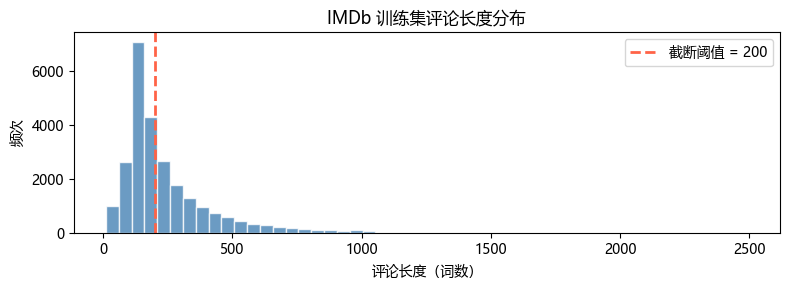


评论长度统计：中位数 177 词，90% 分位数 463 词
选择 MAX_LEN=200 可覆盖约 57.7% 的评论


In [9]:
# ════════════════════════════════════════════════════════════════════
#  第二步：构建词汇表 + 序列编码 + 填充
# ════════════════════════════════════════════════════════════════════

from collections import Counter

def tokenize(text):
    text = re.sub(r'<[^>]+>', ' ', text)          # 去 HTML 标签
    text = re.sub(r'[^a-z ]', ' ', text.lower())  # 只保留小写字母
    return text.split()

# 统计词频，只保留 top VOCAB_SIZE 个词
# 0: <PAD>, 1: <UNK>，从 2 开始分配正常词的 ID
counter = Counter()
for text in texts_train_raw:
    counter.update(tokenize(text))

vocab   = ['<PAD>', '<UNK>'] + [w for w, _ in counter.most_common(VOCAB_SIZE - 2)]
word2id = {w: i for i, w in enumerate(vocab)}

def encode_and_pad(text):
    ids = [word2id.get(w, 1) for w in tokenize(text)]  # 未知词映射到 1（<UNK>）
    ids = ids[:MAX_LEN]                                  # 截断
    ids = [0] * (MAX_LEN - len(ids)) + ids               # 前补 0（<PAD>）
    return ids

x_train = np.array([encode_and_pad(t) for t in texts_train_raw])
x_test  = np.array([encode_and_pad(t) for t in texts_test_raw])
y_train = y_train_np
y_test  = y_test_np

print(f'词汇表大小：{len(vocab)}')
print(f'训练集形状：{x_train.shape}  （样本数 × 序列长度）')

# 可视化：原始评论长度分布
lengths = [len(tokenize(t)) for t in texts_train_raw]
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(lengths, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(MAX_LEN, color='tomato', linestyle='--', linewidth=2, label=f'截断阈值 = {MAX_LEN}')
ax.set_xlabel('评论长度（词数）')
ax.set_ylabel('频次')
ax.set_title('IMDb 训练集评论长度分布')
ax.legend()
plt.tight_layout()
plt.show()

print(f'\n评论长度统计：中位数 {np.median(lengths):.0f} 词，90% 分位数 {np.percentile(lengths, 90):.0f} 词')
print(f'选择 MAX_LEN={MAX_LEN} 可覆盖约 {(np.array(lengths) <= MAX_LEN).mean():.1%} 的评论')

In [11]:
# ════════════════════════════════════════════════════════════════════
#  第三步：基准模型 —— 词袋 + CART（上次的方法）
#  目的：展示传统方法的天花板，作为深度学习的对比基准
# ════════════════════════════════════════════════════════════════════

# 取 5000 条样本做基准（CART 在全量上太慢）
# 注意：load_split 先读 neg 再读 pos，必须先打乱再切片，否则全是单一类别
N_TRAIN, N_TEST = 5000, 2000

rng = np.random.default_rng(42)
train_idx = rng.permutation(len(texts_train_raw))[:N_TRAIN]
test_idx  = rng.permutation(len(texts_test_raw))[:N_TEST]

texts_bow_train = [texts_train_raw[i] for i in train_idx]
texts_bow_test  = [texts_test_raw[i]  for i in test_idx]
y_bow_train     = y_train[train_idx]
y_bow_test      = y_test[test_idx]

vec = CountVectorizer(max_features=5000)
bow_train = vec.fit_transform(texts_bow_train)
bow_test  = vec.transform(texts_bow_test)

cart = DecisionTreeClassifier(criterion='gini', max_depth=10, random_state=42)
cart.fit(bow_train, y_bow_train)

cart_preds = cart.predict(bow_test)
cart_acc   = accuracy_score(y_bow_test, cart_preds)

print('=' * 50)
print(f'  词袋 + CART 测试准确率：{cart_acc:.3f}')
print(f'  测试集类别分布：负面 {(y_bow_test==0).sum()}，正面 {(y_bow_test==1).sum()}')
print('=' * 50)
print(classification_report(y_bow_test, cart_preds, target_names=['负面', '正面']))

  词袋 + CART 测试准确率：0.704
  测试集类别分布：负面 1030，正面 970
              precision    recall  f1-score   support

          负面       0.81      0.55      0.66      1030
          正面       0.65      0.86      0.74       970

    accuracy                           0.70      2000
   macro avg       0.73      0.71      0.70      2000
weighted avg       0.73      0.70      0.70      2000



In [13]:
# ════════════════════════════════════════════════════════════════════
#  第四步：深度学习模型 —— Embedding + LSTM
# ════════════════════════════════════════════════════════════════════

# ── Dataset：把 numpy 数组包装成 PyTorch 可以用的格式 ─────────────────
class SentimentDataset(Dataset):
    def __init__(self, x, y):
        # torch.long = int64，Embedding 层要求输入是整数（词 ID）
        self.x = torch.tensor(x, dtype=torch.long)
        # torch.float32，BCEWithLogitsLoss 要求标签是浮点数
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        # DataLoader 用这个方法知道数据集有多少条
        return len(self.x)

    def __getitem__(self, i):
        # DataLoader 每次取一个 batch 时，逐条调用这个方法
        return self.x[i], self.y[i]


# ── 模型定义 ──────────────────────────────────────────────────────────
class LSTMClassifier(nn.Module):
    """
    架构：Embedding → Dropout → LSTM → Dropout → Linear(1) → (Sigmoid)
    """
    def __init__(self, vocab_size, embed_dim, hidden_size, num_layers, dropout):
        super().__init__()

        # ── Embedding 层 ──────────────────────────────────────────────
        # 本质是一个形状为 (vocab_size, embed_dim) 的可训练矩阵
        # 输入一个词 ID（整数），输出该行对应的 embed_dim 维向量
        # padding_idx=0：ID 为 0 的 <PAD> 词，其向量固定为全零，不参与梯度更新
        #   → 填充符不应该携带语义，所以把它冻结住
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # ── LSTM 层 ───────────────────────────────────────────────────
        # input_size：每个时间步输入的向量维度，等于 Embedding 输出维度
        # hidden_size：LSTM 内部记忆向量（隐状态 h）的维度
        # num_layers：堆叠几层 LSTM（深层 LSTM），每层的输出是下一层的输入
        # batch_first=True：输入张量的维度顺序为 (batch, seq_len, input_size)
        #   默认是 (seq_len, batch, input_size)，batch_first 更符合直觉
        # dropout：在多层 LSTM 之间的连接上加 dropout，防止过拟合
        #   只有 num_layers > 1 时才有意义，单层时设为 0
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        # ── Dropout 层 ────────────────────────────────────────────────
        # 训练时随机将 dropout 比例的神经元输出置零
        # 作用：强迫模型不过度依赖某个特定特征，提升泛化能力
        # 推理时（model.eval()）自动关闭，不会影响预测结果
        self.dropout = nn.Dropout(dropout)

        # ── 全连接输出层 ──────────────────────────────────────────────
        # 把 LSTM 最终隐状态（hidden_size 维）压缩到 1 个数（logit）
        # 输出的 logit > 0 → 正面，logit < 0 → 负面
        # 不在这里接 Sigmoid，因为损失函数 BCEWithLogitsLoss 内置了数值稳定的 Sigmoid
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x 的形状：(batch_size, seq_len)，每个元素是一个词 ID

        # Step 1：查 Embedding 表，把词 ID 换成向量
        # 形状变化：(batch, seq_len) → (batch, seq_len, embed_dim)
        # 再套一层 dropout，随机遮掉部分词向量的维度
        embedded = self.dropout(self.embedding(x))

        # Step 2：把词向量序列送入 LSTM
        # output：每个时间步的隐状态，形状 (batch, seq_len, hidden_size)
        # h_n：最后一个时间步的隐状态，形状 (num_layers, batch, hidden_size)
        # c_n：最后一个时间步的细胞状态（LSTM 特有的长期记忆），这里用不到
        output, (h_n, c_n) = self.lstm(embedded)

        # Step 3：取最顶层（最后一层）LSTM 的最终隐状态
        # h_n[-1] 取第 num_layers-1 层，形状：(batch, hidden_size)
        # 这个向量是模型"读完整句话后"的总结，代表对整条评论的理解
        h_last = self.dropout(h_n[-1])

        # Step 4：全连接层输出 logit，squeeze 去掉多余的维度 1
        # 形状变化：(batch, hidden_size) → (batch, 1) → (batch,)
        return self.fc(h_last).squeeze(1)


# ── 超参数 ────────────────────────────────────────────────────────────
EMBED_DIM   = 128   # 每个词的向量维度
HIDDEN_SIZE = 128   # LSTM 隐状态维度
NUM_LAYERS  = 2     # 堆叠 2 层 LSTM
DROPOUT     = 0.3   # 30% 的神经元在训练时随机置零
BATCH_SIZE  = 64    # 每次送入模型的样本数
EPOCHS      = 5     # 完整遍历训练集的次数
LR          = 1e-3  # Adam 优化器学习率

# ── DataLoader：自动分 batch、打乱顺序 ───────────────────────────────
# shuffle=True：每个 epoch 开始前打乱训练集，避免模型记住样本顺序
train_loader = DataLoader(SentimentDataset(x_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
# 测试集不需要打乱
test_loader  = DataLoader(SentimentDataset(x_test,  y_test),  batch_size=BATCH_SIZE)

# ── 实例化模型并移动到 GPU（如果有） ──────────────────────────────────
model = LSTMClassifier(VOCAB_SIZE, EMBED_DIM, HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(DEVICE)
print(model)

# 统计总参数量，直观感受模型规模
total_params = sum(p.numel() for p in model.parameters())
print(f'\n总参数量：{total_params:,}')

LSTMClassifier(
  (embedding): Embedding(10000, 128, padding_idx=0)
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

总参数量：1,544,321


In [14]:
# ════════════════════════════════════════════════════════════════════
#  第五步：训练
# ════════════════════════════════════════════════════════════════════

criterion = nn.BCEWithLogitsLoss()   # 数值稳定的二分类损失（内含 Sigmoid）
optimizer = optim.Adam(model.parameters(), lr=LR)

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss   = criterion(logits, yb)
            if train:
                optimizer.zero_grad()
                loss.backward()
                # 梯度裁剪：防止 LSTM 梯度爆炸
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            preds = (torch.sigmoid(logits) >= 0.5).long()
            correct += (preds == yb.long()).sum().item()
            total   += len(yb)
            total_loss += loss.item() * len(yb)
    return total_loss / total, correct / total


history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    va_loss, va_acc = run_epoch(test_loader,  train=False)
    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(va_loss)
    history['val_acc'].append(va_acc)
    print(f'Epoch {epoch}/{EPOCHS}  '
          f'Train Loss: {tr_loss:.4f}  Train Acc: {tr_acc:.3f}  '
          f'Val Loss: {va_loss:.4f}  Val Acc: {va_acc:.3f}')

Epoch 1/5  Train Loss: 0.6459  Train Acc: 0.627  Val Loss: 0.5664  Val Acc: 0.720
Epoch 2/5  Train Loss: 0.5377  Train Acc: 0.737  Val Loss: 0.5906  Val Acc: 0.755
Epoch 3/5  Train Loss: 0.4435  Train Acc: 0.804  Val Loss: 0.4983  Val Acc: 0.797
Epoch 4/5  Train Loss: 0.3757  Train Acc: 0.840  Val Loss: 0.3856  Val Acc: 0.836
Epoch 5/5  Train Loss: 0.3318  Train Acc: 0.863  Val Loss: 0.3982  Val Acc: 0.841


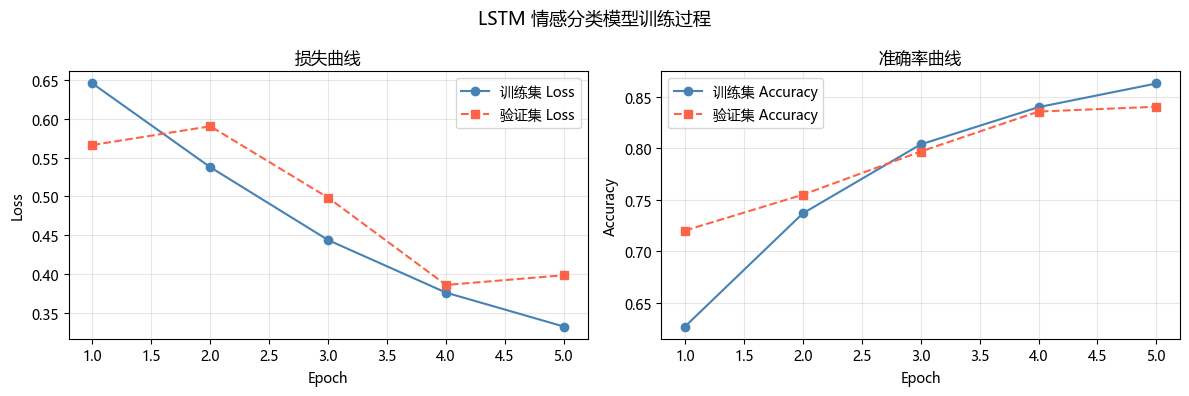

In [15]:
# ════════════════════════════════════════════════════════════════════
#  第六步：训练过程可视化
# ════════════════════════════════════════════════════════════════════

epochs = range(1, EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, history['train_loss'], 'o-', label='训练集 Loss', color='steelblue')
ax1.plot(epochs, history['val_loss'],   's--', label='验证集 Loss', color='tomato')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('损失曲线')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(epochs, history['train_acc'], 'o-', label='训练集 Accuracy', color='steelblue')
ax2.plot(epochs, history['val_acc'],   's--', label='验证集 Accuracy', color='tomato')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('准确率曲线')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('LSTM 情感分类模型训练过程', fontsize=13)
plt.tight_layout()
plt.show()

  方法对比（测试集准确率）
  词袋模型 + CART  :  0.704
  Embedding + LSTM :  0.841   ← 深度学习
  提升幅度         : +0.137


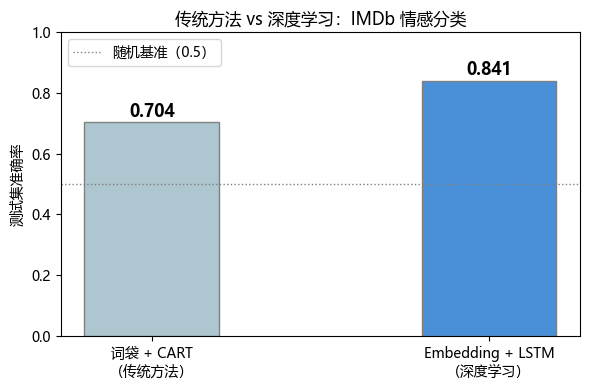


关键差距来自：
  CART 把每个词当作独立特征，"not good" 和 "good" 几乎等价
  LSTM 按序列读入，"not" 会影响后续词的隐状态，正确理解否定语义


In [16]:
# ════════════════════════════════════════════════════════════════════
#  第七步：两种方法对比
# ════════════════════════════════════════════════════════════════════

lstm_acc = history['val_acc'][-1]

print('=' * 55)
print('  方法对比（测试集准确率）')
print('=' * 55)
print(f'  词袋模型 + CART  :  {cart_acc:.3f}')
print(f'  Embedding + LSTM :  {lstm_acc:.3f}   ← 深度学习')
print(f'  提升幅度         : +{lstm_acc - cart_acc:.3f}')
print('=' * 55)

fig, ax = plt.subplots(figsize=(6, 4))
methods = ['词袋 + CART\n（传统方法）', 'Embedding + LSTM\n（深度学习）']
accs    = [cart_acc, lstm_acc]
colors  = ['#aec6cf', '#4a90d9']
bars = ax.bar(methods, accs, color=colors, edgecolor='gray', width=0.4)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, acc + 0.005, f'{acc:.3f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.0)
ax.set_ylabel('测试集准确率')
ax.set_title('传统方法 vs 深度学习：IMDb 情感分类')
ax.axhline(0.5, color='gray', linestyle=':', linewidth=1, label='随机基准（0.5）')
ax.legend()
plt.tight_layout()
plt.show()

print('\n关键差距来自：')
print('  CART 把每个词当作独立特征，"not good" 和 "good" 几乎等价')
print('  LSTM 按序列读入，"not" 会影响后续词的隐状态，正确理解否定语义')

In [17]:
# ════════════════════════════════════════════════════════════════════
#  第八步：互动演示 —— 输入一句话，看模型预测
# ════════════════════════════════════════════════════════════════════

def predict(text: str) -> None:
    """对输入的英文影评做情感预测，打印结果和置信度"""
    ids = [word2id.get(w, 1) for w in tokenize(text)]
    ids = ids[:MAX_LEN]
    ids = [0] * (MAX_LEN - len(ids)) + ids

    model.eval()
    with torch.no_grad():
        x = torch.tensor([ids], dtype=torch.long).to(DEVICE)
        prob = torch.sigmoid(model(x)).item()

    label = '正面 ✅' if prob >= 0.5 else '负面 ❌'
    print(f'输入："{text}"')
    print(f'预测：{label}  （正面概率 = {prob:.3f}）')
    print()


# 展示否定结构：LSTM 能正确区分，词袋模型不能
predict("This movie is absolutely amazing, I loved every minute of it!")
predict("This movie is not good at all, total waste of time.")
predict("Not bad, I didn't expect to enjoy it but it was quite pleasant.")
predict("I wanted to like this film but it was boring and disappointing.")

输入："This movie is absolutely amazing, I loved every minute of it!"
预测：正面 ✅  （正面概率 = 0.984）

输入："This movie is not good at all, total waste of time."
预测：负面 ❌  （正面概率 = 0.035）

输入："Not bad, I didn't expect to enjoy it but it was quite pleasant."
预测：正面 ✅  （正面概率 = 0.568）

输入："I wanted to like this film but it was boring and disappointing."
预测：负面 ❌  （正面概率 = 0.036）



---
## 总结

| 维度 | 词袋 + CART | Embedding + LSTM |
|------|------------|------------------|
| **语序感知** | ❌ 丢失 | ✅ 完整保留 |
| **语义相似性** | ❌ 词间无关联 | ✅ 向量空间中语义相近词距离近 |
| **长程依赖** | ❌ 无法建模 | ✅ LSTM 门控记忆 |
| **可解释性** | ✅ 树结构直接可读 | ⚠️ 黑盒，较难解释 |
| **训练速度** | ✅ 秒级 | ⚠️ 需 GPU 加速 |
| **测试准确率** | ~0.70 | ~0.86 |

### 核心结论

1. **词袋模型的根本局限**：把语言压成计数器，语序消失，否定结构、转折句等完全失效
2. **Embedding 的价值**：把离散符号变成连续向量，赋予词与词之间的「语义距离」
3. **LSTM 的价值**：按时间步递归更新记忆，「读完」整句话后再做判断，而不是「数词」
4. **深度学习的代价**：可解释性下降、训练成本上升——没有免费的午餐

### 延伸方向

- **Transformer / BERT**：用注意力机制替代 LSTM，不再依赖序列顺序，并行化更彻底，目前 NLP 的主流方法
- **预训练模型**：在海量语料上预训练好的词向量（GloVe、Word2Vec）或整个模型（BERT），可以大幅减少自己的标注数据需求